# Matemáticas aplicadas. Parcial 3

#### Samuel Acosta Aristizábal - 1000900513
#### Manuela Caro Villada - 1000124254
#### Jeronimo Velasquez Escobar - 1000116682

In [181]:
## Se inicialializa el programa y se importan las librerias necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Ejercicio numero 1

In [182]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame
X = cancer.data[['mean radius', 'mean texture']]
y = cancer.target
X

,mean radius,mean texture
0,17.99,10.38
1,20.57,17.77
2,19.69,21.25
3,11.42,20.38
4,20.29,14.34
...,...,...
564,21.56,22.39
565,20.13,28.25
566,16.60,28.08
567,20.60,29.33


In [183]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [184]:
# for col in X.columns:
#     mean = X[col].mean()
#     std = X[col].std()
#     X[col] = (X[col] - mean) / std
# X.mean()

In [185]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [186]:
# Verificacion
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[-2.92806072e-16  6.24652955e-16]
[1. 1.]


In [187]:
y_train_svm = (2*y_train - 1).values
y_test_svm = (2*y_test - 1).values

In [188]:
class LinearSVM_SGD:

    def __init__(self, lr=0.01, C=1.0, epochs=1000):
        self.lr = lr
        self.C = C
        self.epochs = epochs
        self.cost_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):

            idx = np.random.randint(0, n_samples)

            xi = X[idx]
            yi = y[idx]

            condition = yi * (np.dot(xi, self.w) + self.b)

            if condition >= 1:
                grad_w = self.w
                grad_b = 0
            else:
                grad_w = self.w - self.C * yi * xi
                grad_b = -self.C * yi

            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

            # costo completo (para graficar)
            margins = y * (X @ self.w + self.b)
            hinge_loss = np.maximum(0, 1 - margins)
            cost = 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge_loss)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

In [189]:
class LinearSVM_GD:

    def __init__(self, lr=0.01, C=1.0, epochs=1000):
        self.lr = lr
        self.C = C
        self.epochs = epochs
        self.cost_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):

            margins = y * (X @ self.w + self.b)

            # identificar puntos que violan el margen
            mask = margins < 1

            # gradiente promedio
            grad_w = self.w - self.C * np.mean((y[mask][:, None] * X[mask]), axis=0)
            grad_b = -self.C * np.mean(y[mask]) if np.any(mask) else 0

            # actualización
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

            # calcular costo
            hinge_loss = np.maximum(0, 1 - margins)
            cost = 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge_loss)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

In [190]:
svm_SGD = LinearSVM_SGD(lr=0.05, C=1.0, epochs=3000)
svm_SGD.fit(X_train_scaled, y_train_svm)

In [191]:
svm_GD = LinearSVM_GD(lr=0.1, C=1.0, epochs=3000)
svm_GD.fit(X_train_scaled, y_train_svm)

In [193]:
print("Pesos:", svm_GD.w)
print("Bias:", svm_GD.b)
preds = svm_GD.predict(X_test_scaled)

accuracy = np.mean(preds == y_test_svm)
print("Accuracy:", accuracy)

Pesos: [-0.54564892 -0.23604662]
Bias: 0.5795540235938501
Accuracy: 0.8421052631578947


In [194]:
print("Pesos:", svm_SGD.w)
print("Bias:", svm_SGD.b)
preds = svm_SGD.predict(X_test_scaled)

accuracy = np.mean(preds == y_test_svm)
print("Accuracy:", accuracy)

Pesos: [-0.52794614 -0.32687575]
Bias: 0.49999999999999983
Accuracy: 0.8508771929824561


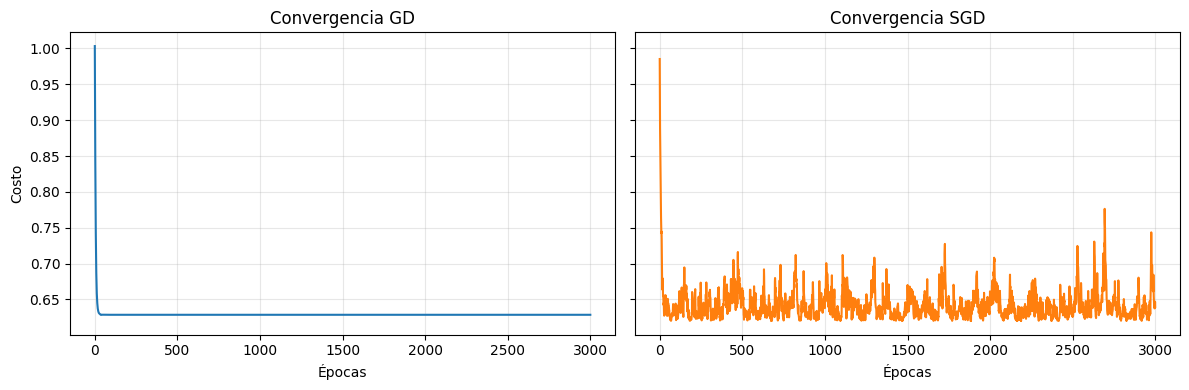

In [196]:
# Cambio del costo en subplots distintos
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(svm_GD.cost_history, color="tab:blue")
axes[0].set_title("Convergencia GD")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Costo")
axes[0].grid(True, alpha=0.3)

axes[1].plot(svm_SGD.cost_history, color="tab:orange")
axes[1].set_title("Convergencia SGD")
axes[1].set_xlabel("Épocas")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [197]:
C_values = [0.01, 1, 100, 10]  # valor adicional = 10

In [198]:
def plot_svm(ax, model, X, y, title):

    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.7)

    x1 = np.linspace(X[:,0].min(), X[:,0].max(), 100)

    w1, w2 = model.w
    b = model.b

    # frontera decisión
    x2 = (-w1*x1 - b) / w2
    ax.plot(x1, x2, 'k')

    # márgenes
    x2_margin1 = (-w1*x1 - b + 1) / w2
    x2_margin2 = (-w1*x1 - b - 1) / w2

    ax.plot(x1, x2_margin1, 'k--')
    ax.plot(x1, x2_margin2, 'k--')

    ax.set_title(title)

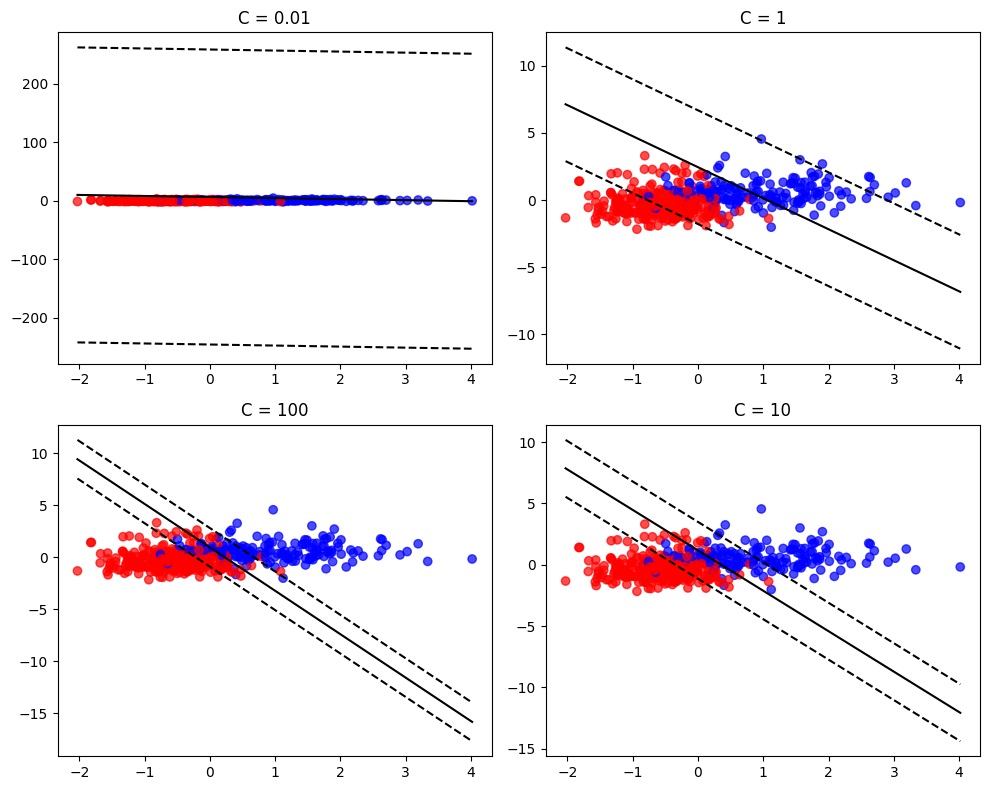

In [199]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

for ax, C in zip(axes.flatten(), C_values):

    model = LinearSVM_GD(lr=0.01, C=C, epochs=1000)
    model.fit(X_train_scaled, y_train_svm)

    plot_svm(ax, model, X_train_scaled, y_train_svm, f"C = {C}")

plt.tight_layout()
plt.show()

#### Ejercicio 1.4


##### (a) Oscilaciones en SGD

Sí, la curva de costo del SGD presenta oscilaciones.

Esto ocurre porque el gradiente se calcula utilizando un único punto aleatorio en cada iteración, lo que introduce ruido en la dirección de descenso. A diferencia del GD, que usa el gradiente promedio sobre todos los datos, el SGD produce actualizaciones estocásticas que pueden incrementar temporalmente el costo.

Desde una perspectiva computacional, el SGD es indispensable cuando el conjunto de datos es extremadamente grande (por ejemplo, un millón de imágenes médicas), ya que calcular el gradiente completo en cada iteración sería prohibitivo en términos de memoria y tiempo. El SGD permite actualizaciones rápidas y escalables.

---

##### (b) Efecto geométrico de C

Al aumentar el valor de C:

El margen se vuelve más estrecho.

Se penalizan más severamente las violaciones.

Disminuye la tolerancia a errores.

Geométricamente, el hiperplano se ajusta más a los datos.

En un contexto clínico, un C moderado (por ejemplo C=1 o C=10) probablemente generalice mejor, ya que evita tanto el sobreajuste como el subajuste.

--- 

##### (c) ¿Cuáles son los vectores de soporte?

Son los puntos que cumplen:

yi​(wTxi​+b)≤1

Es decir:

Puntos sobre el margen

Puntos dentro del margen

Puntos mal clasificados

Son los únicos que contribuyen al gradiente.

---
##### (d) ¿Qué pasa con puntos bien clasificados y fuera del margen?

Si:

yi​(wTxi​+b)>1
	​

Entonces:

max(0,1−yi​(wTxi​+b))=0

y su contribución al gradiente es cero.

Matemáticamente:

∂w/∂J​=w

Es decir, el punto no influye en la actualización.

Esto es una propiedad fundamental del:

Support Vector Machine

solo los vectores de soporte afectan la solución.